In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import h5py
import os
print(os.getpid())
%cd ../../

import pylib.mix as mix

from matplotlib import colors


plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

79228
c:\Users\ivan9\Documents\work\codes\QuCF\scripts-py


In [2]:
path_save_ = "./jupyter-notebooks/Carleman/results/"
for i in range(100):
    plt.close()

# colors_     = ["blue", "red", "green", "gray", "black"]
colors_     = ["orange", "red", "green", "gray", 'yellow', 'purple', 'pink', 'brown',]
linestyles_ = ["-", "--", "--", ":"]

In [ ]:
# ---------------------------------------------------------------
# --- Prepare the system ---
# ---------------------------------------------------------------
mix.reload_module(mix)

# sel_case_ = 2  # several fixed points in a single chart
sel_case_ = 100 # ref globalisation
# sel_case_ = 10 # option 2: ref globalisation


# --- 1 attractor and an unstable point: chosen cases ---
if sel_case_ == 10:
    print("a single attractor and an unstable point")
    case_title_ = "unstable"
    N_nl_orig_ = 2
    F_terms_ = [None] * (N_nl_orig_ + 1)

    a1, b1,   tmax_, x_centers_ = 0.1, -1.6,   4.0, [-0.9] # converge to the stable point
    # a1, b1,   tmax_, x_centers_ = 0.1, -1.6,   1.6, [0.2] # excape the unstable point

    F_ = lambda x:  (a1 - x) * (b1 - x)
    # F_terms_[2], F_terms_[1], F_terms_[0] = 1., -(a1 + b1), a1*b1 

    sys_coefs_ = {}
    sys_coefs_["a"] = a1
    sys_coefs_["b"] = b1

    def return_sys(ss):
        a1 = ss["a"]
        b1 = ss["b"]
        F_terms = [None] * (N_nl_orig_ + 1)
        F_terms[2], F_terms[1], F_terms[0] = 1., -(a1 + b1), a1*b1 
        return F_terms
    
    def shift_coefs_f_(ss, zeta):
        ss_new = {}
        for key, value in ss.items():
            ss_new[key] = value - zeta
        return ss_new
    
    def shift_x(x, zeta):
        x = x + zeta
        return x
    
    # --- Print the system ---
    print("\nSystem coefficients:")
    for key, value in sys_coefs_.items():
        print("{:s} = {:0.3f}".format(key, value))
    print()

    F_terms_ = return_sys(sys_coefs_)
# --- 2 attractors and an unstable point ---
if sel_case_ == 2:
    print("two attractors and an unstable point")
    case_title_ = "fps_one_chart"
    tmax_ = 8.0
    x_centers_ = [-0.95 + 0.05 * ii for ii in range(40)]

    N_nl_orig_ = 3
    F_terms_ = [None] * (N_nl_orig_ + 1)
    
    a1, b1, c1 = 0.4, -0.1, -0.6

    F_ = lambda x:  (a1 - x) * (b1 - x) * (c1 - x)

    sys_coefs_ = {}
    sys_coefs_["a"] = a1
    sys_coefs_["b"] = b1
    sys_coefs_["c"] = c1

    def return_sys(ss):
        a1 = ss["a"]
        b1 = ss["b"]
        c1 = ss["c"]
        F_terms = [None] * (N_nl_orig_ + 1)
        F_terms[3], F_terms[2], F_terms[1], F_terms[0] = -1., (a1 + b1 + c1), -(a1*b1 + a1*c1 + b1*c1), a1*b1*c1
        return F_terms

    def shift_coefs_f_(ss, zeta):
        ss_new = {}
        for key, value in ss.items():
            ss_new[key] = value - zeta
        return ss_new
    
    def shift_x(x, zeta):
        x = x + zeta
        return x
    
    # --- Print the system ---
    print("\nSystem coefficients:")
    for key, value in sys_coefs_.items():
        print("{:s} = {:0.3f}".format(key, value))
    print()

    F_terms_ = return_sys(sys_coefs_)
# --- 2 attractors and an unstable point: chosen cases for globalization ---
if sel_case_ == 100:
    print("two attractors and an unstable point: globalization")
    case_title_ = "fps_several_charts"

    tmax_ = 1.4
    x_centers_ = x_centers_ = [-0.90 + 0.20 * ii for ii in range(9)]
    N_nl_orig_ = 3

    a1, b1, c1 = 1.6, 0.2, -2.2

    F_ = lambda x:  (a1 - x) * (b1 - x) * (c1 - x)  # b1 is an unstable fixed point

    sys_coefs_ = {}
    sys_coefs_["a"] = a1
    sys_coefs_["b"] = b1
    sys_coefs_["c"] = c1

    def return_sys(ss):
        a1 = ss["a"]
        b1 = ss["b"]
        c1 = ss["c"]
        F_terms = [None] * (N_nl_orig_ + 1)
        F_terms[3], F_terms[2], F_terms[1], F_terms[0] = -1., (a1 + b1 + c1), -(a1*b1 + a1*c1 + b1*c1), a1*b1*c1
        return F_terms

    def shift_coefs_f_(ss, zeta):
        ss_new = {}
        for key, value in ss.items():
            ss_new[key] = value - zeta
        return ss_new
    
    def shift_x(x, zeta):
        x = x + zeta
        return x
    
    # --- Print the system ---
    print("\nSystem coefficients:")
    for key, value in sys_coefs_.items():
        print("{:s} = {:0.3f}".format(key, value))
    print()

    F_terms_ = return_sys(sys_coefs_)
# ------------------------------------------------------------------------------
nt_ = 9
Nt_ = 1 << nt_
t_ = np.linspace(0, tmax_, Nt_)
dt_ = np.diff(t_)[0]

flag_save_ = False

two attractors and an unstable point: globalization

System coefficients:
a = 1.600
b = 0.200
c = -2.200



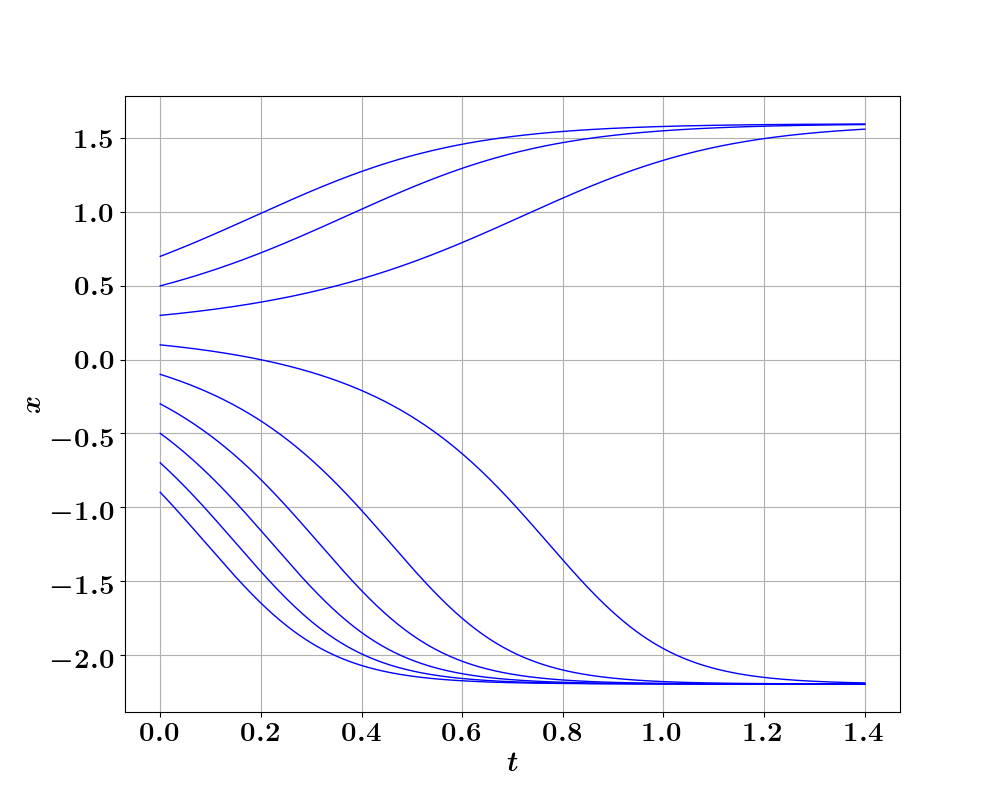

In [17]:
# -----------------------------------------------------------------
# --- Standard method (for reference) ---
# -----------------------------------------------------------------
from scipy.integrate import RK45
mix.reload_module(mix)
def solve_standart(x_center_ref):
    oo = RK45(
        lambda t,x: F_(x), 
        t_[0], 
        [x_center_ref], t_[-1], first_step=dt_, max_step=dt_
    )
    
    sol_ref = np.zeros(Nt_, dtype=float)
    t_res = np.zeros(Nt_)
    sol_ref[0] = x_center_ref
    Nt_act = 1
    while mix.compare_two_strings(oo.status, "running"):
        oo.step()
        Nt_act += 1
        if (Nt_act - 1) >= len(t_res):
            # print("\nWARNING: increase arrays: counter_t = {:d}".format(Nt_act - 1))
            t_res = np.pad(t_res, (0, Nt_), 'constant')
            sol_ref = np.pad(sol_ref, (0, Nt_), mode='constant')

        t_res[Nt_act - 1] = oo.t
        sol_ref[Nt_act-1] = float(oo.y[0])
    t_res = t_res[:Nt_act]
    sol_ref = sol_ref[:Nt_act]
    return sol_ref, t_res
# --------------------------------------------------------------------------
def analyse_classical(fontsize = 20, fig_size = (10,8)):
    sol_refs = []

    fig, ax = plt.subplots(1, 1, figsize=fig_size)
    # ax = fig.add_subplot(111)
    for i_center in range(len(x_centers_)):
        x_center = x_centers_[i_center]

        # --- Solve for the particular x_center ---
        sol_one, t = solve_standart(x_center)
        sol_refs.append(sol_one)

        # if i_center == 0:
        #     print(t[0])

        # --- Plotting ---
        ax.plot(
            t, sol_one, 
            "b", 
            linewidth = 1, linestyle='-', 
        )
        del x_center
    ax.set_xlabel('$t$', fontsize = fontsize)
    ax.set_ylabel("$x$", fontsize = fontsize)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    plt.grid(True)
    plt.show()
    return
# --------------------------------------------------------------------------
analyse_classical()

--- Carleman solver with globalisation ---
zeta_th = 0.10
x_loc, t_global, zeta_gl: -4.059e-01, 2.740e-03, -1.000e-01
x_loc, t_global, zeta_gl: -3.119e-01, 5.479e-03, -2.000e-01
x_loc, t_global, zeta_gl: -2.180e-01, 8.219e-03, -3.000e-01
x_loc, t_global, zeta_gl: -1.241e-01, 1.096e-02, -4.000e-01
x_loc, t_global, zeta_gl: -1.022e-01, 4.384e-02, -5.000e-01
x_loc, t_global, zeta_gl: -1.069e-01, 8.305e-02, -6.000e-01
x_loc, t_global, zeta_gl: -1.038e-01, 1.156e-01, -7.000e-01
x_loc, t_global, zeta_gl: -1.055e-01, 1.469e-01, -8.000e-01
x_loc, t_global, zeta_gl: -1.066e-01, 1.760e-01, -9.000e-01
x_loc, t_global, zeta_gl: -1.038e-01, 2.024e-01, -1.000e+00
x_loc, t_global, zeta_gl: -1.015e-01, 2.281e-01, -1.100e+00
x_loc, t_global, zeta_gl: -1.099e-01, 2.559e-01, -1.200e+00
x_loc, t_global, zeta_gl: -1.057e-01, 2.803e-01, -1.300e+00
x_loc, t_global, zeta_gl: -1.069e-01, 3.064e-01, -1.400e+00
x_loc, t_global, zeta_gl: -1.064e-01, 3.329e-01, -1.500e+00
x_loc, t_global, zeta_gl: -1.006e-01, 3.59

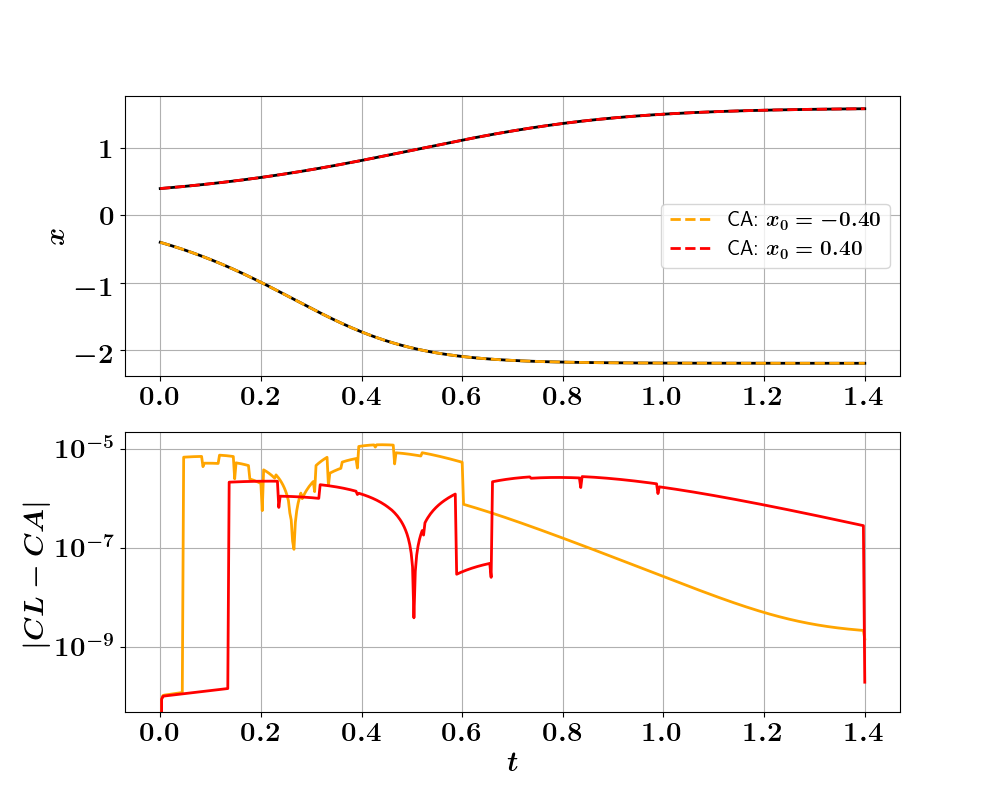

In [19]:
# --------------------------------------------------------------------
# --- Compare trajectories ---
# --------------------------------------------------------------------
from scipy.integrate import RK45
import random
mix.reload_module(mix)
def solve_carleman(x_init, N_nl):
    def f_to_RK(t, x):
        f_eqs = np.dot(A, x) + B
        return f_eqs
    # --------------------------------------------------------------
    # --- Form the system ---
    B = np.zeros(N_nl)
    B[0] = F_terms_[0]

    A       = np.zeros((N_nl, N_nl))
    xs_init = np.zeros(N_nl)
    for ir in range(N_nl):
        xs_init[ir] = x_init**(ir + 1)

        c1 = 1 + ir
        A[ir,ir] = c1 * F_terms_[1]

        # element to the left from the main diagonal
        if ir > 0:
            A[ir, ir-1] = c1 * F_terms_[0]

        # elements to the right from the main diagonal   
        for i_nl in range(N_nl_orig_ - 1):
            if ir < (N_nl - (i_nl + 1)):
                A[ir, ir + 1 + i_nl] = c1 * F_terms_[2 + i_nl]
    del c1

    # --- Runge-Kutta solver ---
    oo = RK45(
        f_to_RK,
        t_[0], 
        xs_init, 
        t_[-1], first_step=dt_, max_step=dt_
    )
    sol_carleman      = np.zeros((Nt_, N_nl))
    sol_carleman[0,:] = xs_init
    Nt_act = 1

    t_res = np.zeros(Nt_)

    # oo.step()
    # t_res[Nt_act - 1] = oo.t
    while mix.compare_two_strings(oo.status, "running"):
        oo.step()
        Nt_act += 1
        if (Nt_act - 1) >= len(t_res):
            # print("WARNING: increase arrays: counter_t = {:d}".format(Nt_act - 1))
            t_res = np.pad(t_res, (0, Nt_), 'constant')
            sol_carleman = np.pad(sol_carleman, ((0, Nt_), (0, 0)), mode='constant')

        t_res[Nt_act - 1] = oo.t
        sol_carleman[Nt_act-1,:] = oo.y.copy()
    t_res = t_res[:Nt_act]
    sol_carleman = sol_carleman[:Nt_act]
    return sol_carleman, t_res
# -----------------------------------------------------------------------
def solve_carleman_inv(x_init, N_nl):
    def f_to_RK(t, x):
        f_eqs = np.dot(A, x) + B
        return f_eqs
    # --------------------------------------------------------------
    # --- Form the system ---
    sh_inv_ord = int(N_nl_orig_ - 2)  # assume that the original nonlinearity is at least quadratic

    # *** matrix B ***
    B = np.zeros(N_nl)
    for ii in range(sh_inv_ord + 1):
        B[ii] = - (ii + 1) * F_terms_[2 + ii]

    # *** Initial conditions and matrix A ***
    A       = np.zeros((N_nl, N_nl))
    xs_init = np.zeros(N_nl)
    for ir in range(N_nl):
        # *** initial conditions ***
        xs_init[ir] = x_init**(-(ir + 1))

        # *** matrix A ***
        c1 = - (1 + ir)

        # main diagonal
        A[ir,ir] = c1 * F_terms_[1]

        # left sidebands
        for i_nl in range(N_nl_orig_ - 1):
            if ir > i_nl:
                A[ir, ir - 1 - i_nl] = c1 * F_terms_[2 + i_nl]

        # right sideband
        if ir < (N_nl - 1):
            A[ir, ir+1] = c1 * F_terms_[0]
    del c1

    # --- Runge-Kutta solver ---
    oo = RK45(
        f_to_RK,
        t_[0], 
        xs_init, 
        t_[-1], first_step=dt_, max_step=dt_
    )
    sol_carleman      = np.zeros((Nt_, N_nl))
    sol_carleman[0,:] = xs_init
    Nt_act = 1
    t_res = np.zeros(Nt_)

    # oo.step()
    # t_res[Nt_act - 1] = oo.t
    while mix.compare_two_strings(oo.status, "running"):
        oo.step()
        Nt_act += 1
        if (Nt_act - 1) >= len(t_res):
            # print("\nWARNING: increase arrays: counter_t = {:d}".format(Nt_act - 1))
            t_res = np.pad(t_res, (0, Nt_), 'constant')
            sol_carleman = np.pad(sol_carleman, ((0, Nt_), (0, 0)), mode='constant')

        t_res[Nt_act - 1] = oo.t
        sol_carleman[Nt_act-1,:] = oo.y.copy()
    t_res = t_res[:Nt_act]
    sol_carleman = sol_carleman[:Nt_act]
    return sol_carleman, t_res
# -----------------------------------------------------------------------
def solve_carleman_global(x_init_cond, N_nl, zeta_th = 0.6, eta_t = 1.):
    def f_to_RK(t, x):
        f_eqs = np.dot(A_sys, x) + B_sys
        return f_eqs
    # --------------------------------------------------------------
    def form_system(F_terms, x_init_loc):
        # --- Form the system ---
        B = np.zeros(N_nl)
        B[0] = F_terms[0]

        A       = np.zeros((N_nl, N_nl))
        xs_init_loc = np.zeros(N_nl)
        for ir in range(N_nl):
            xs_init_loc[ir] = x_init_loc**(ir + 1)

            c1 = 1 + ir
            A[ir,ir] = c1 * F_terms[1]

            # element to the left from the main diagonal
            if ir > 0:
                A[ir, ir-1] = c1 * F_terms[0]

            # elements to the right from the main diagonal   
            for i_nl in range(N_nl_orig_ - 1):
                if ir < (N_nl - (i_nl + 1)):
                    A[ir, ir + 1 + i_nl] = c1 * F_terms[2 + i_nl]
        del c1
        return A, B, xs_init_loc
    # --------------------------------------------------------------

    # --- original system coefficients ---
    print("zeta_th = {:0.2f}".format(zeta_th))
    zeta_gl = 0.

    x_init_curr = x_init_cond
    t_global = 0.
    Nt_act = 1

    t_res = np.zeros(Nt_)
    sol_carleman = np.zeros((Nt_, 1))

    # --- form the original system ---
    while t_global < t_[-1]:
        A_sys, B_sys, xs_init_sys = form_system(
            return_sys(shift_coefs_f_(sys_coefs_, zeta_gl)), 
            x_init_curr
        )
        
        # --- Runge-Kutta solver ---
        # oo = RK45(f_to_RK, t_global, xs_init_sys, t_[-1], first_step=dt_/eta_t, max_step=dt_)
        oo = RK45(f_to_RK, t_global, xs_init_sys, t_[-1], max_step=dt_)
        sol_carleman[Nt_act - 1, 0] = shift_x(xs_init_sys[0], zeta_gl)
        while mix.compare_two_strings(oo.status, "running"):
            oo.step()
            Nt_act += 1
            if (Nt_act - 1) >= len(t_res):
                print()
                print("WARNING: increase arrays: counter_t = {:d}".format(Nt_act - 1))
                t_res = np.pad(t_res, (0, Nt_), 'constant')
                sol_carleman = np.pad(sol_carleman, ((0, Nt_), (0, 0)), mode='constant')
                print("new size of t array: {:d}".format(len(t_res)))
                print()

            t_res[Nt_act - 1] = oo.t
            t_global          = t_res[Nt_act - 1]
            # print("counter, t: {:d}, {:0.3f}".format(Nt_act, t_res[Nt_act - 1]))

            res = oo.y.copy()
            x_loc = res[0]
            if np.abs(x_loc) >= zeta_th:
                sign_loc = x_loc / np.abs(x_loc)
                zeta_curr = sign_loc*zeta_th
                zeta_gl += zeta_curr

                x_init_curr = shift_x(x_loc, -zeta_curr)
                print("x_loc, t_global, zeta_gl: {:0.3e}, {:0.3e}, {:0.3e}".format(x_loc, t_global, zeta_gl))
                break
            else:
                sol_carleman[Nt_act-1, 0] = shift_x(x_loc, zeta_gl)

    # --- remove empty cells from the resulting lists ---    
    t_res = t_res[:Nt_act]
    sol_carleman = sol_carleman[:Nt_act]
    return sol_carleman, t_res
# ------------------------------------------------------------------------------------
def compare_trajectory_cl_and_carleman(
        x_inits, N_nl, 
        sel_solver = 0, zeta_th = 0.6, eta_t = 1.0,
        fontsize = 20, fig_size = (10,8)
):
    # -----------------------------------------
    # >>> sel_solver:
    # 0: solve_carleman
    # 1: solve_carleman_inv
    # 2: solve_carleman_global
    # -----------------------------------------
    fontsize_leg = int(fontsize/4. * 3.)

    N_init = len(x_inits)
    cl_res = [None] * N_init
    x_ca = [None] * N_init
    t_cl = [None] * N_init
    t_res = [None] * N_init
    for ii in range(N_init):
        cl_res[ii], t_cl[ii] = solve_standart(x_inits[ii])
        if sel_solver == 0:
            print("--- Standard Carleman solver ---")
            ca_res, t_res[ii] = solve_carleman(x_inits[ii], N_nl)
            x_ca[ii] = ca_res[:,0]
            emb_opt = "STD"
        elif sel_solver == 1:
            print("--- Carleman solver with an inverse basis ---")
            ca_res, t_res[ii] = solve_carleman_inv(x_inits[ii], N_nl)
            x_ca[ii] = ca_res[:,0]**(-1)
            emb_opt = "INV"
        else:
            print("--- Carleman solver with globalisation ---")
            ca_res, t_res[ii] = solve_carleman_global(x_inits[ii], N_nl, zeta_th, eta_t)
            x_ca[ii] = ca_res[:,0]
            emb_opt = "GL"

    # print(t_res[0])
            
    # --- plotting --
    fig, axs = plt.subplots(2, 1, figsize=fig_size)
    for ii in range(N_init):
        if ii >= len(colors_):
            col = "#{:06x}".format(random.randint(0, 0xFFFFFF))
        else:
            col = colors_[ii]

        axs[0].plot(
            t_cl[ii], cl_res[ii], 
            color="black", linewidth = 2, linestyle='-'
        )
        axs[0].plot(
            t_res[ii], x_ca[ii], 
            color=col, linewidth = 2, linestyle="--", 
            label = "CA: $x_0 = {:0.2f}$".format(x_inits[ii])
        )

        # --- Save data ---
        if flag_save_:
            mix.save_dat_plot_1d_file(
                path_save_ + "/REF_{:s}_IC{:0.2f}_x.dat".format(case_title_, x_inits[ii]), 
                t_cl[ii], cl_res[ii]
            )
            mix.save_dat_plot_1d_file(
                path_save_ + "/EMB_{:s}_{:s}_IC{:0.2f}_x.dat".format(emb_opt, case_title_, x_inits[ii]), 
                t_res[ii], x_ca[ii]
            )

    axs[0].set_ylabel("$x$", fontsize = fontsize)
    offset_text = axs[0].yaxis.get_offset_text()
    offset_text.set_fontsize(fontsize) 

    axs[0].legend(fontsize = fontsize_leg)
    axs[0].grid(True)
    axs[0].tick_params(axis='both', which='major', labelsize=fontsize)
    # axs[0].set_xticklabels([])

    # ---
    for ii in range(N_init):
        if ii >= len(colors_):
            col = "#{:06x}".format(random.randint(0, 0xFFFFFF))
        else:
            col = colors_[ii]
    
        x_ca_inter = np.interp(t_cl[ii], t_res[ii], x_ca[ii])
        axs[1].semilogy(
            t_cl[ii], np.abs(cl_res[ii] - x_ca_inter), 
            color=col, linewidth = 2, linestyle='-', 
            # label = "$x_0 = {:0.2f}$".format(x_inits[ii])
        )

        # --- Save data ---
        if flag_save_:
            mix.save_dat_plot_1d_file(
                path_save_ + "/EMB_{:s}_{:s}_IC{:0.2f}_err.dat".format(emb_opt, case_title_, x_inits[ii]), 
                t_cl[ii], np.abs(cl_res[ii] - x_ca_inter)
            )
    axs[1].set_xlabel('$t$', fontsize = fontsize)
    axs[1].set_ylabel("$|CL - CA|$", fontsize = fontsize)
    offset_text = axs[1].yaxis.get_offset_text()
    offset_text.set_fontsize(fontsize) 

    # axs[1].legend(fontsize = fontsize_leg)
    axs[1].grid(True)
    axs[1].tick_params(axis='both', which='major', labelsize=fontsize)
    return
# ------------------------------------------------------------------------------------
N_nl = 6

# --- for the case with 0.4, -0.1, -0.6 ---
if sel_case_ == 2:
    x_inits = [0.6, 0.2, -0.2, -0.9]  # for sel_
elif sel_case_ == 100:
    x_inits = [-0.4, 0.4]
else:
    x_inits = x_centers_

# compare_trajectory_cl_and_carleman(x_inits, N_nl, sel_solver = 0)
compare_trajectory_cl_and_carleman(x_inits, N_nl, sel_solver = 2, zeta_th = 0.1, eta_t = 10.)